# Web Scraping (Data Collection)

In [569]:
from bs4 import BeautifulSoup
import re
import pandas as pd
import requests
import time

In [570]:
publishers = [
    "фабрика комиксов", "комильфо", "азбука", "истари комикс", "аст", "эксмо", "xl media", "миф (манн, иванов и фербер)", "бумкнига", "бомбора", "кислород", "азбука-аттикус", "белое яблоко", "молодая гвардия", "вече", "родина", "рипол классик", "колибри", "амфора", "общественный фонд «мазмұндама»", "прозаик", "евразия", "омега-л", "inspiria", "t8rugram", "иностранка", "книжный клуб 36.6", "clever", "metamorphoses", "дом историй", "freedom", "fanzon", "like book", "феникс", "rugram_publishing", "черным-бело"
]
subsections = [134, 142, 135, 970, 158]
genres = {
    134: 'Фантастика',
    142: 'Романы',
    135: 'Боевики',
    970: 'Манга и комиксы',
    158: 'Биография'
}
all_books_data = []
seen_ids = set()

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36 Edg/147.0.0.0"
}

for sub in subsections:
    for page in range(2, 3):
        url = f'https://www.flip.kz/catalog?subsection={sub}&page={page}'
        try:
          response = requests.get(url, headers=headers)
          response.encoding = 'utf-8'
          if response.status_code != 200:
              print(f"Error on {page}: {response.status_code}")
              break
          soup = BeautifulSoup(response.text, 'html.parser')
          all_books = soup.find_all('div', class_='new-product')
          for book in all_books:
            try:
              link_tag = book.find('a', class_='product')
              if not link_tag:
                  continue
              link = link_tag.get('href')
              book_id = link.split('prod=')[-1]
              if book_id in seen_ids:
                  continue
              seen_ids.add(book_id)
              title = book.find('div', class_='title').text.strip()
              price = book.find('div', class_='price').find('span').text.strip() if book.find('div', class_='price') else "No price"
              discount = book.find('span', class_='produce-label red').text.strip() if book.find('span', class_='produce-label red') else 'No discount'
              bonus = '0'
              bonuses = book.find_all('span', class_='produce-label') if book.find('span', class_='produce-label') else []
              for b in bonuses:
                  value = b.get_text(strip=True)
                  if '+' in value:
                      bonus = value
                      break
              description = book.find('div', class_='description').get_text(separator=', ', strip=True) if book.find('div', class_='description') else ""
              parts = description.split(', ')
              cover = 'Unknown'
              year = '0'
              publisher = 'Unknown'
              for p in parts:
                p_pb = p.strip().lower()
                for pub in publishers:
                  if pub in p_pb:
                    publisher = p.strip()
                    break
              for p in parts:
                  p = p.strip().lower()
                  if p.isdigit() and len(p) == 4:
                      year = p
                  elif any(word in p for word in ['обложка', 'переплет', 'картон', 'винил', 'пластик']):
                      cover = p
                  elif all(forbidden not in p for forbidden in ['г/м²', 'лист', 'см', 'шт']):
                      if publisher == 'Unknown':
                          publisher = p
              rating = book.find('span', class_='round').text.strip() if book.find('span', class_='round') else 'Not rated'
              reviews = book.find('span', class_='go-to-reviews').text.strip() if book.find('span', class_='go-to-reviews') else '0'
              stock = book.find('div', class_='delivery').text.strip() if book.find('div', class_='delivery') else 'Unknown'
              all_books_data.append({
                  'genre': genres.get(sub, 'Другое'),
                  'title': title,
                  'price': price,
                  'discount': discount,
                  'bonus': bonus,
                  'cover': cover,
                  'year': year,
                  'publisher': publisher,
                  'rating': rating,
                  'reviews': reviews,
                  'stock': stock
              })
            except Exception as book_error:
                  print(f"Erri=or on page {page}: {book_error}")
                  continue
          time.sleep(1.2)
        except requests.exceptions.RequestException as e:
            print(f"Error {page}: {e}")
            time.sleep(5)
            continue
df = pd.DataFrame(all_books_data)
df.to_csv('flip_books_original.csv', index=False, encoding='utf-8-sig')

In [571]:
df

,genre,title,price,discount,bonus,cover,year,publisher,rating,reviews,stock
0,Фантастика,Кэрри,3 765 ₸,No discount,+38,твердый переплет,2013,АСТ,4.8,112 отзывов,На складе
1,Фантастика,Система «Спаси-Себя-Сам» для Главного Злодея. ...,9 509 ₸,-20%,+95,твердый переплет,2024,Эксмо,5.0,34 отзыва,На складе
2,Фантастика,Точка зрения Всеведущего читателя. Том 2,4 551 ₸,-30%,+46,твердый переплет,2026,Кислород,5.0,5 отзывов,На складе
3,Фантастика,Перси Джексон и море Чудовищ,3 919 ₸,-20%,+39,твердый переплет,2022,Эксмо,5.0,20 отзывов,На складе
4,Фантастика,Кэрри,2 133 ₸,No discount,+21,мягкая обложка,2020,АСТ,4.7,77 отзывов,На складе
...,...,...,...,...,...,...,...,...,...,...,...
295,Биография,50 правил Коко Шанель,4 072 ₸,-20%,+41,твердый переплет,2025,Эксмо,5.0,1 отзыв,На складе
296,Биография,Becoming,10 606 ₸,-25%,+106,мягкая обложка,2021,random house - penguin,5.0,1 отзыв,8 мая
297,Биография,Rammstein. Горящие сердца,3 595 ₸,-15%,+36,твердый переплет,2020,АСТ,4.5,2 отзыва,На складе
298,Биография,Жизнь гейши. Мемуары самой известной гейши,4 603 ₸,-20%,+46,твердый переплет,2023,Бомбора,4.8,10 отзывов,На складе


# Data Cleaning & Transformation

In [572]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

In [573]:
df_raw = pd.read_csv('flip_books_original.csv')
df = df_raw.copy()

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
df.head(5)

Dataset shape: 300 rows × 11 columns



,genre,title,price,discount,bonus,cover,year,publisher,rating,reviews,stock
0,Фантастика,Кэрри,3 765 ₸,No discount,38,твердый переплет,2013,АСТ,4.8,112 отзывов,На складе
1,Фантастика,Система «Спаси-Себя-Сам» для Главного Злодея. ...,9 509 ₸,-20%,95,твердый переплет,2024,Эксмо,5.0,34 отзыва,На складе
2,Фантастика,Точка зрения Всеведущего читателя. Том 2,4 551 ₸,-30%,46,твердый переплет,2026,Кислород,5.0,5 отзывов,На складе
3,Фантастика,Перси Джексон и море Чудовищ,3 919 ₸,-20%,39,твердый переплет,2022,Эксмо,5.0,20 отзывов,На складе
4,Фантастика,Кэрри,2 133 ₸,No discount,21,мягкая обложка,2020,АСТ,4.7,77 отзывов,На складе


Remove Duplicates

In [574]:
full_dups = df.duplicated().sum()
df = df.drop_duplicates()
print(f'Full duplicates removed: {full_dups}')

Full duplicates removed: 0


Clean Price Column

In [575]:
print('BEFORE:', df['price'].head(3).tolist())
df["price"] = df["price"].astype(str).str.replace(r"[^\d]", "", regex=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["price"] = df["price"].astype("Int64")
print('AFTER: ', df['price'].head(3).tolist())
df.dropna(subset=['price'], inplace=True)
df.head()

BEFORE: ['3\u202f765\u202f₸', '9\u202f509\u202f₸', '4\u202f551\u202f₸']
AFTER:  [3765, 9509, 4551]


,genre,title,price,discount,bonus,cover,year,publisher,rating,reviews,stock
0,Фантастика,Кэрри,3765,No discount,38,твердый переплет,2013,АСТ,4.8,112 отзывов,На складе
1,Фантастика,Система «Спаси-Себя-Сам» для Главного Злодея. ...,9509,-20%,95,твердый переплет,2024,Эксмо,5.0,34 отзыва,На складе
2,Фантастика,Точка зрения Всеведущего читателя. Том 2,4551,-30%,46,твердый переплет,2026,Кислород,5.0,5 отзывов,На складе
3,Фантастика,Перси Джексон и море Чудовищ,3919,-20%,39,твердый переплет,2022,Эксмо,5.0,20 отзывов,На складе
4,Фантастика,Кэрри,2133,No discount,21,мягкая обложка,2020,АСТ,4.7,77 отзывов,На складе


Clean Discount Column

In [576]:
df["discount"] = (df["discount"].str.replace(r"[^\d]", "", regex=True).replace("", "0").astype(float))
print(f"discount range: {df['discount'].min()} – {df['discount'].max()}%")
df["discount"].value_counts().head(10)

discount range: 0.0 – 75.0%


,count
discount,
0.0,115
20.0,103
15.0,40
25.0,17
40.0,9
35.0,7
30.0,6
55.0,1
75.0,1


Clean Rating Column

In [577]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

In [578]:
df['rating'] = df['rating'].astype('float')

In [579]:
df['rating']

,rating
0,4.8
1,5.0
2,5.0
3,5.0
4,4.7
...,...
295,5.0
296,5.0
297,4.5
298,4.8


Clean Discount Column

In [580]:
df['publisher'] = df['publisher'].str.capitalize()
df['publisher'].head()

,publisher
0,Аст
1,Эксмо
2,Кислород
3,Эксмо
4,Аст


Clean Reviews Column

In [581]:
df["review_count"] = df["reviews"].str.extract(r"(\d+)").astype(float).fillna(0).astype(int)

Fix Invalid Year Values

In [582]:
invalid_year = df["year"] == 0
df.loc[invalid_year, "year"] = np.nan
df["year"] = df["year"].astype("Int64")
df["year_missing"] = invalid_year

print(f"Year range (valid): {df['year'].min()} – {df['year'].max()}")

Year range (valid): 2010 – 2026


In [583]:
df.loc[df['year'] == 1793, 'year'] = 2022

In [584]:
df


,genre,title,price,discount,bonus,cover,year,publisher,rating,reviews,stock,review_count,year_missing
0,Фантастика,Кэрри,3765,0.0,38,твердый переплет,2013,Аст,4.8,112 отзывов,На складе,112,False
1,Фантастика,Система «Спаси-Себя-Сам» для Главного Злодея. ...,9509,20.0,95,твердый переплет,2024,Эксмо,5.0,34 отзыва,На складе,34,False
2,Фантастика,Точка зрения Всеведущего читателя. Том 2,4551,30.0,46,твердый переплет,2026,Кислород,5.0,5 отзывов,На складе,5,False
3,Фантастика,Перси Джексон и море Чудовищ,3919,20.0,39,твердый переплет,2022,Эксмо,5.0,20 отзывов,На складе,20,False
4,Фантастика,Кэрри,2133,0.0,21,мягкая обложка,2020,Аст,4.7,77 отзывов,На складе,77,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Биография,50 правил Коко Шанель,4072,20.0,41,твердый переплет,2025,Эксмо,5.0,1 отзыв,На складе,1,False
296,Биография,Becoming,10606,25.0,106,мягкая обложка,2021,Random house - penguin,5.0,1 отзыв,8 мая,1,False
297,Биография,Rammstein. Горящие сердца,3595,15.0,36,твердый переплет,2020,Аст,4.5,2 отзыва,На складе,2,False
298,Биография,Жизнь гейши. Мемуары самой известной гейши,4603,20.0,46,твердый переплет,2023,Бомбора,4.8,10 отзывов,На складе,10,False


Standardize Stock / Availability

In [585]:
months = {
    'января':1,'февраля':2,'марта':3,'апреля':4,'мая':5,'июня':6,
    'июля':7,'августа':8,'сентября':9,'октября':10,'ноября':11,'декабря':12
}

def parse_stock(val):
    val = str(val).strip()
    return 'In stock' if val == 'На складе' else 'Preorder'

def stock_to_date_str(val):
    val = str(val).strip().lower()
    if val == 'на складе':
        return '2026-04-27'
    if val == 'завтра':
        return '2026-04-28'
    for m_name, m_num in months.items():
        if m_name in val:
            match = re.search(r'\d+', val)
            if match:
                day = int(match.group())
                return f'2026-{m_num:02d}-{day:02d}'
    return None

df['stock_status'] = df['stock'].apply(parse_stock)
df['stock'] = df['stock'].apply(stock_to_date_str)


In [586]:
df

,genre,title,price,discount,bonus,cover,year,publisher,rating,reviews,stock,review_count,year_missing,stock_status
0,Фантастика,Кэрри,3765,0.0,38,твердый переплет,2013,Аст,4.8,112 отзывов,2026-04-27,112,False,In stock
1,Фантастика,Система «Спаси-Себя-Сам» для Главного Злодея. ...,9509,20.0,95,твердый переплет,2024,Эксмо,5.0,34 отзыва,2026-04-27,34,False,In stock
2,Фантастика,Точка зрения Всеведущего читателя. Том 2,4551,30.0,46,твердый переплет,2026,Кислород,5.0,5 отзывов,2026-04-27,5,False,In stock
3,Фантастика,Перси Джексон и море Чудовищ,3919,20.0,39,твердый переплет,2022,Эксмо,5.0,20 отзывов,2026-04-27,20,False,In stock
4,Фантастика,Кэрри,2133,0.0,21,мягкая обложка,2020,Аст,4.7,77 отзывов,2026-04-27,77,False,In stock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Биография,50 правил Коко Шанель,4072,20.0,41,твердый переплет,2025,Эксмо,5.0,1 отзыв,2026-04-27,1,False,In stock
296,Биография,Becoming,10606,25.0,106,мягкая обложка,2021,Random house - penguin,5.0,1 отзыв,2026-05-08,1,False,Preorder
297,Биография,Rammstein. Горящие сердца,3595,15.0,36,твердый переплет,2020,Аст,4.5,2 отзыва,2026-04-27,2,False,In stock
298,Биография,Жизнь гейши. Мемуары самой известной гейши,4603,20.0,46,твердый переплет,2023,Бомбора,4.8,10 отзывов,2026-04-27,10,False,In stock


In [587]:
df['stock'] = pd.to_datetime(df['stock'], errors='coerce')
df.dtypes

,0
genre,object
title,object
price,Int64
discount,float64
bonus,int64
cover,object
year,Int64
publisher,object
rating,float64
reviews,object


Text Normalization

In [588]:
def normalize_cover(val):
    val = str(val).strip().lower()
    if "твердый" in val or "твердая" in val:
        return "Hardcover"
    elif "супер" in val:
        return "Supercover"
    else:
        return "Paperback"

df["cover_type"] = df["cover"].apply(normalize_cover)

Outlier Detection & Handling

In [589]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = df[(df["price"] < lower) | (df["price"] > upper)]
print(f"Price IQR boarders: [{lower:.0f};  {upper:.0f}]")
print(f"Outliers detected: {len(price_outliers)} rows")

Price IQR boarders: [-3041;  13327]
Outliers detected: 9 rows


Feature Engineering

In [590]:
df["original_price"] = (df["price"] / (1 - df["discount"] / 100)).round(0).astype(float)
df[["title", "price", "discount", "original_price"]].head(5)

,title,price,discount,original_price
0,Кэрри,3765,0.0,3765.0
1,Система «Спаси-Себя-Сам» для Главного Злодея. ...,9509,20.0,11886.0
2,Точка зрения Всеведущего читателя. Том 2,4551,30.0,6501.0
3,Перси Джексон и море Чудовищ,3919,20.0,4899.0
4,Кэрри,2133,0.0,2133.0


In [591]:
df['discount_bin'] = pd.cut(df['discount'], bins=[-1, 5, 15, 30, 100],
                                     labels=['Minimal (0-5%)', 'Low (5-15%)', 'Medium (15-30%)', 'High (30%+)'])

In [592]:
df['price'].max()

np.int64(48693)

In [593]:
bins   = [0, 1500, 3000, 5000, 8000, 57378]
labels = ["Budget (<1.5k)", "Economy (1.5-3k)", "Mid (3-5k)",
          "Premium (5-8k)", "Luxury (8k+)"]

df["price_bucket"] = pd.cut(df["price"], bins=bins, labels=labels, right=True)
df["price_bucket"].value_counts().sort_index()

,count
price_bucket,
Budget (<1.5k),3
Economy (1.5-3k),71
Mid (3-5k),105
Premium (5-8k),64
Luxury (8k+),57


In [594]:
df["savings_tenge"] = df["original_price"] - df["price"]
print(f"Max savings: {df['savings_tenge'].max()}")
df[df["savings_tenge"] > 0][["title", "savings_tenge"]].head(5)

Max savings: 9308.0


,title,savings_tenge
1,Система «Спаси-Себя-Сам» для Главного Злодея. ...,2377.0
2,Точка зрения Всеведущего читателя. Том 2,1950.0
3,Перси Джексон и море Чудовищ,980.0
5,Пять ночей у Фредди. Серебряные глаза,980.0
9,Королевство серебряного пламени. Королевство с...,2047.0


In [595]:
df["popularity_score"] = np.where(df["rating"].notnull() & (df["review_count"] > 0),(df["rating"] / 5.0) * np.log1p(df["review_count"]),np.nan)
print(f"Max score: {df['popularity_score'].max():.3f}")
display(df.nlargest(5, "popularity_score")[["title", "rating", "review_count", "popularity_score"]])

Max score: 5.375


,title,rating,review_count,popularity_score
87,Цветы для Элджернона,4.9,240,5.375101
70,Твое сердце будет разбито,4.8,219,5.177882
18,Злой король,4.9,183,5.110637
123,Труп в библиотеке,4.8,193,5.057144
146,Портрет Дориана Грея,4.9,170,5.038830


In [596]:
df["price_per_bonus"] = np.where(df["bonus"] > 0,(df["price"] / df["bonus"]).round(2),np.nan)
df["price_per_bonus"].head()

,price_per_bonus
0,99.08
1,100.09
2,98.93
3,100.49
4,101.57


In [597]:
df_raw.head()

,genre,title,price,discount,bonus,cover,year,publisher,rating,reviews,stock
0,Фантастика,Кэрри,3 765 ₸,No discount,38,твердый переплет,2013,АСТ,4.8,112 отзывов,На складе
1,Фантастика,Система «Спаси-Себя-Сам» для Главного Злодея. ...,9 509 ₸,-20%,95,твердый переплет,2024,Эксмо,5.0,34 отзыва,На складе
2,Фантастика,Точка зрения Всеведущего читателя. Том 2,4 551 ₸,-30%,46,твердый переплет,2026,Кислород,5.0,5 отзывов,На складе
3,Фантастика,Перси Джексон и море Чудовищ,3 919 ₸,-20%,39,твердый переплет,2022,Эксмо,5.0,20 отзывов,На складе
4,Фантастика,Кэрри,2 133 ₸,No discount,21,мягкая обложка,2020,АСТ,4.7,77 отзывов,На складе


In [598]:
df.head()

,genre,title,price,discount,bonus,cover,year,publisher,rating,reviews,...,review_count,year_missing,stock_status,cover_type,original_price,discount_bin,price_bucket,savings_tenge,popularity_score,price_per_bonus
0,Фантастика,Кэрри,3765,0.0,38,твердый переплет,2013,Аст,4.8,112 отзывов,...,112,False,In stock,Hardcover,3765.0,Minimal (0-5%),Mid (3-5k),0.0,4.538292,99.08
1,Фантастика,Система «Спаси-Себя-Сам» для Главного Злодея. ...,9509,20.0,95,твердый переплет,2024,Эксмо,5.0,34 отзыва,...,34,False,In stock,Hardcover,11886.0,Medium (15-30%),Luxury (8k+),2377.0,3.555348,100.09
2,Фантастика,Точка зрения Всеведущего читателя. Том 2,4551,30.0,46,твердый переплет,2026,Кислород,5.0,5 отзывов,...,5,False,In stock,Hardcover,6501.0,Medium (15-30%),Mid (3-5k),1950.0,1.791759,98.93
3,Фантастика,Перси Джексон и море Чудовищ,3919,20.0,39,твердый переплет,2022,Эксмо,5.0,20 отзывов,...,20,False,In stock,Hardcover,4899.0,Medium (15-30%),Mid (3-5k),980.0,3.044522,100.49
4,Фантастика,Кэрри,2133,0.0,21,мягкая обложка,2020,Аст,4.7,77 отзывов,...,77,False,In stock,Paperback,2133.0,Minimal (0-5%),Economy (1.5-3k),0.0,4.095306,101.57


In [599]:
df.columns

Index(['genre', 'title', 'price', 'discount', 'bonus', 'cover', 'year',
       'publisher', 'rating', 'reviews', 'stock', 'review_count',
       'year_missing', 'stock_status', 'cover_type', 'original_price',
       'discount_bin', 'price_bucket', 'savings_tenge', 'popularity_score',
       'price_per_bonus'],
      dtype='object')

In [600]:
col_order = [
    'title', 'publisher', 'year', 'year_missing', 'cover', 'cover_type',
    'price', 'discount', 'original_price', 'savings_tenge', 'price_bucket',
    'bonus', 'price_per_bonus', 'rating',
    'review_count', 'popularity_score', 'stock', 'stock_status', 'genre', 'discount_bin'
]
df_final = df[col_order]

df_raw2 = pd.read_csv('flip_books_original.csv')

comparison = pd.DataFrame({
    'Metric': [
        'Total rows', 'Total columns', 'Duplicate rows',
        'Price dtype', 'Reviews dtype', 'Invalid years (year = 0)',
        '"Not rated" in rating', 'Cover type variants', 'New engineered features'
    ],
    'BEFORE (raw)': [
        df_raw2.shape[0], df_raw2.shape[1],
        int(df_raw2.duplicated().sum()),
        'object — "9 509 ₸"', 'object — "34 отзыва"',
        int((df_raw2['year'] == 0).sum()),
        int((df_raw2['rating'] == 'Not rated').sum()),
        int(df_raw2['cover'].nunique()), 0
    ],
    'AFTER (clean)': [
         df_final.shape[0],
         df_final.shape[1],
         0,
        "Int64",
        "int64",
        (df_final["year"] == 0).sum(),
        (df_final["rating"] == "Not rated").sum(),
        df_final["cover_type"].nunique(),
        5,
]
})

print(comparison.to_string(index=False))

df_final.to_csv('flip_cleaned.csv', index=False, encoding='utf-8-sig')
print(f"\n Saved! Final dataset: {df_final.shape[0]} rows × {df_final.shape[1]} columns")

from google.colab import files
files.download('flip_cleaned.csv')

                  Metric         BEFORE (raw) AFTER (clean)
              Total rows                  300           300
           Total columns                   11            20
          Duplicate rows                    0             0
             Price dtype   object — "9 509 ₸"         Int64
           Reviews dtype object — "34 отзыва"         int64
Invalid years (year = 0)                    2             0
   "Not rated" in rating                   29             0
     Cover type variants                   12             3
 New engineered features                    0             5

 Saved! Final dataset: 300 rows × 20 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [601]:
comparison

,Metric,BEFORE (raw),AFTER (clean)
0,Total rows,300,300
1,Total columns,11,20
2,Duplicate rows,0,0
3,Price dtype,"object — ""9 509 ₸""",Int64
4,Reviews dtype,"object — ""34 отзыва""",int64
5,Invalid years (year = 0),2,0
6,"""Not rated"" in rating",29,0
7,Cover type variants,12,3
8,New engineered features,0,5


# Exploratory Data Analysis (EDA)

In [602]:
df_final.describe()

,year,price,discount,original_price,savings_tenge,bonus,price_per_bonus,rating,review_count,popularity_score,stock
count,298.0,300.0,300.000000,300.000000,300.0,300.000000,300.000000,271.000000,300.000000,271.000000,300
mean,2021.865772,5610.533333,13.483333,6622.640000,1012.106667,56.126667,99.988300,4.900369,26.713333,2.635094,2026-04-28 09:31:12
min,2010.0,797.0,0.000000,996.000000,0.0,8.000000,97.330000,4.000000,0.000000,0.554518,2026-04-27 00:00:00
25%,2021.0,3097.0,0.000000,3560.000000,0.0,30.750000,99.560000,4.800000,2.000000,1.609438,2026-04-27 00:00:00
50%,2023.0,4544.5,15.000000,5242.000000,657.0,45.500000,99.910000,5.000000,11.500000,2.776549,2026-04-27 00:00:00
75%,2024.0,7189.0,20.000000,8594.000000,1501.75,72.000000,100.472500,5.000000,36.000000,3.572752,2026-04-27 00:00:00
max,2026.0,48693.0,75.000000,57286.000000,9308.0,487.000000,103.000000,5.000000,240.000000,5.375101,2026-05-09 00:00:00
std,3.132662,4310.778355,12.313480,5139.796298,1374.12784,43.139704,0.815339,0.138911,38.246662,1.210999,NaN


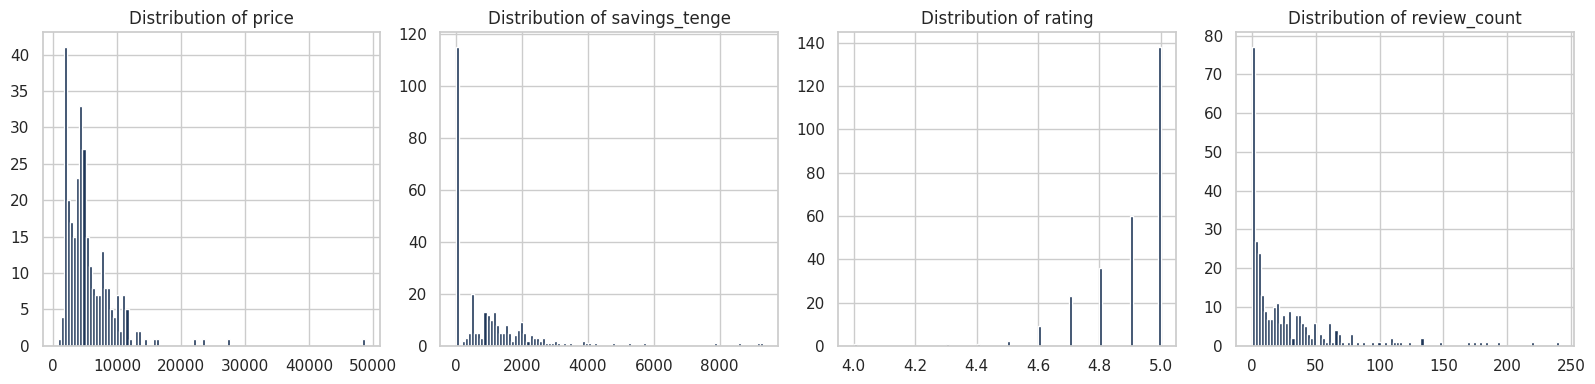

In [603]:
import matplotlib.pyplot as plt
cols_to_check=['price','savings_tenge','rating','review_count']
fig,axes=plt.subplots(1,4,figsize=(16,4))
for i, col in enumerate(cols_to_check):
    axes[i].hist(df_final[col], bins=100, color='#1d3557', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [604]:
df_final.corr(numeric_only=True)

,year,year_missing,price,discount,original_price,savings_tenge,bonus,price_per_bonus,rating,review_count,popularity_score
year,1.000000,NaN,0.118373,0.279097,0.146030,0.175340,0.118783,-0.117443,0.251145,-0.361470,-0.470841
year_missing,NaN,1.000000,0.037748,-0.023214,0.019180,-0.046676,0.036852,0.143088,0.030864,0.010270,0.057292
price,0.118373,0.037748,1.000000,-0.011241,0.972898,0.501934,0.999977,-0.035742,0.202693,-0.201612,-0.290421
discount,0.279097,-0.023214,-0.011241,1.000000,0.188844,0.741617,-0.011096,-0.036502,0.227316,-0.243303,-0.316583
original_price,0.146030,0.019180,0.972898,0.188844,1.000000,0.688325,0.972904,-0.037141,0.247096,-0.243180,-0.368909
savings_tenge,0.175340,-0.046676,0.501934,0.741617,0.688325,1.000000,0.502025,-0.026797,0.231209,-0.277114,-0.376831
bonus,0.118783,0.036852,0.999977,-0.011096,0.972904,0.502025,1.000000,-0.041707,0.202361,-0.201881,-0.290816
price_per_bonus,-0.117443,0.143088,-0.035742,-0.036502,-0.037141,-0.026797,-0.041707,1.000000,-0.004885,0.062567,0.076241
rating,0.251145,0.030864,0.202693,0.227316,0.247096,0.231209,0.202361,-0.004885,1.000000,-0.288100,-0.341256
review_count,-0.361470,0.010270,-0.201612,-0.243303,-0.243180,-0.277114,-0.201881,0.062567,-0.288100,1.000000,0.812082


In [605]:
display(df_final)

,title,publisher,year,year_missing,cover,cover_type,price,discount,original_price,savings_tenge,price_bucket,bonus,price_per_bonus,rating,review_count,popularity_score,stock,stock_status,genre,discount_bin
0,Кэрри,Аст,2013,False,твердый переплет,Hardcover,3765,0.0,3765.0,0.0,Mid (3-5k),38,99.08,4.8,112,4.538292,2026-04-27,In stock,Фантастика,Minimal (0-5%)
1,Система «Спаси-Себя-Сам» для Главного Злодея. ...,Эксмо,2024,False,твердый переплет,Hardcover,9509,20.0,11886.0,2377.0,Luxury (8k+),95,100.09,5.0,34,3.555348,2026-04-27,In stock,Фантастика,Medium (15-30%)
2,Точка зрения Всеведущего читателя. Том 2,Кислород,2026,False,твердый переплет,Hardcover,4551,30.0,6501.0,1950.0,Mid (3-5k),46,98.93,5.0,5,1.791759,2026-04-27,In stock,Фантастика,Medium (15-30%)
3,Перси Джексон и море Чудовищ,Эксмо,2022,False,твердый переплет,Hardcover,3919,20.0,4899.0,980.0,Mid (3-5k),39,100.49,5.0,20,3.044522,2026-04-27,In stock,Фантастика,Medium (15-30%)
4,Кэрри,Аст,2020,False,мягкая обложка,Paperback,2133,0.0,2133.0,0.0,Economy (1.5-3k),21,101.57,4.7,77,4.095306,2026-04-27,In stock,Фантастика,Minimal (0-5%)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,50 правил Коко Шанель,Эксмо,2025,False,твердый переплет,Hardcover,4072,20.0,5090.0,1018.0,Mid (3-5k),41,99.32,5.0,1,0.693147,2026-04-27,In stock,Биография,Medium (15-30%)
296,Becoming,Random house - penguin,2021,False,мягкая обложка,Paperback,10606,25.0,14141.0,3535.0,Luxury (8k+),106,100.06,5.0,1,0.693147,2026-05-08,Preorder,Биография,Medium (15-30%)
297,Rammstein. Горящие сердца,Аст,2020,False,твердый переплет,Hardcover,3595,15.0,4229.0,634.0,Mid (3-5k),36,99.86,4.5,2,0.988751,2026-04-27,In stock,Биография,Low (5-15%)
298,Жизнь гейши. Мемуары самой известной гейши,Бомбора,2023,False,твердый переплет,Hardcover,4603,20.0,5754.0,1151.0,Mid (3-5k),46,100.07,4.8,10,2.301979,2026-04-27,In stock,Биография,Medium (15-30%)


In [606]:
df_final.groupby('cover_type')[['price','discount']].mean()

,price,discount
cover_type,,
Hardcover,6430.328205,14.333333
Paperback,3124.747253,11.153846
Supercover,10349.571429,16.785714


In [607]:
df_final.groupby('price_bucket')['price'].mean()

,price
price_bucket,
Budget (<1.5k),1215.333333
Economy (1.5-3k),2245.211268
Mid (3-5k),4159.809524
Premium (5-8k),6423.84375
Luxury (8k+),11792.947368


In [608]:
df_final.groupby('publisher')['savings_tenge'].sum()

,savings_tenge
publisher,
Clever,11123.0
Corpus,0.0
Fanzon. fantasy world. большой покет с клапанами,0.0
Freedom,3719.0
Freedom. проза софи анри. миры магии и любви,1218.0
Inspiria,1931.0
Like book,913.0
Marshmallow books,1175.0
Random house - penguin,3535.0


In [609]:
df_final.groupby('cover_type')['popularity_score'].mean()

,popularity_score
cover_type,
Hardcover,2.425970
Paperback,3.062737
Supercover,2.483893


In [610]:
df_final.groupby('publisher')['rating'].mean().tail(3)

,rating
publisher,
Эксмо,4.913636
Яуза,5.000000
Яуза-пресс,4.900000


In [611]:
df_final.groupby('price_bucket')['review_count'].sum()

,review_count
price_bucket,
Budget (<1.5k),13
Economy (1.5-3k),2850
Mid (3-5k),3387
Premium (5-8k),823
Luxury (8k+),941


In [612]:
df_final.groupby('stock_status')['popularity_score'].mean()

,popularity_score
stock_status,
In stock,2.818205
Preorder,1.805491


In [613]:
df_final.groupby(['stock_status','price_bucket']).size()

stock_status  price_bucket    
In stock      Budget (<1.5k)       3
              Economy (1.5-3k)    68
              Mid (3-5k)          91
              Premium (5-8k)      48
              Luxury (8k+)        26
Preorder      Budget (<1.5k)       0
              Economy (1.5-3k)     3
              Mid (3-5k)          14
              Premium (5-8k)      16
              Luxury (8k+)        31
dtype: int64

In [614]:
df_final.groupby('publisher')['price_per_bonus'].mean()

,price_per_bonus
publisher,
Clever,100.445000
Corpus,99.820000
Fanzon. fantasy world. большой покет с клапанами,100.220000
Freedom,100.072857
Freedom. проза софи анри. миры магии и любви,99.390000
Inspiria,99.640000
Like book,98.730000
Marshmallow books,100.000000
Random house - penguin,100.060000


In [615]:
df['rating'].unique()

array([4.8, 5. , 4.7, 4.9, nan, 4.6, 4.4, 4.5, 4. , 4.3])

In [616]:
top_deals = df_final[df_final['rating'] > 0].sort_values(by=['discount', 'rating'], ascending=False).head(5)
top_deals

,title,publisher,year,year_missing,cover,cover_type,price,discount,original_price,savings_tenge,price_bucket,bonus,price_per_bonus,rating,review_count,popularity_score,stock,stock_status,genre,discount_bin
270,Сокровища кочевника: Париж и далее везде,Аст,2023,False,твердый переплет,Hardcover,2608,75.0,10432.0,7824.0,Economy (1.5-3k),26,100.31,5.0,1,0.693147,2026-04-27,In stock,Биография,High (30%+)
227,Темные ночи. Металл смерти. Книга 1,Азбука,2022,False,твердый переплет,Hardcover,7616,55.0,16924.0,9308.0,Premium (5-8k),76,100.21,5.0,1,0.693147,2026-04-27,In stock,Манга и комиксы,High (30%+)
254,Репортаж с петлей на шее,Альпина паблишер,2023,False,твердый переплет,Hardcover,2585,40.0,4308.0,1723.0,Economy (1.5-3k),26,99.42,5.0,1,0.693147,2026-04-27,In stock,Биография,High (30%+)
260,Мисс Остин,Бель летр,2025,False,мягкая обложка,Paperback,3187,40.0,5312.0,2125.0,Mid (3-5k),32,99.59,5.0,1,0.693147,2026-05-06,Preorder,Биография,High (30%+)
266,Записки примата. Необычайная жизнь учёного,Альпина нон-фикшн,2023,False,мягкая обложка,Paperback,4247,40.0,7078.0,2831.0,Mid (3-5k),42,101.12,5.0,2,1.098612,2026-05-06,Preorder,Биография,High (30%+)


In [617]:
expensive_bonuses=df_final.sort_values(by='price_per_bonus',ascending=False).head(5)
expensive_bonuses

,title,publisher,year,year_missing,cover,cover_type,price,discount,original_price,savings_tenge,price_bucket,bonus,price_per_bonus,rating,review_count,popularity_score,stock,stock_status,genre,discount_bin
267,Письма к друзьям,Аст,2013,False,мягкая обложка,Paperback,1442,15.0,1696.0,254.0,Budget (<1.5k),14,103.00,4.9,12,2.513650,2026-04-27,In stock,Биография,Low (5-15%)
114,Грозовой перевал,Азбука - классика,<NA>,True,мягкая обложка,Paperback,1845,20.0,2306.0,461.0,Economy (1.5-3k),18,102.50,4.9,27,3.265560,2026-04-27,In stock,Романы,Medium (15-30%)
7,Солярис,Аст,2014,False,мягкая обложка,Paperback,2444,0.0,2444.0,0.0,Economy (1.5-3k),24,101.83,4.9,56,3.962190,2026-04-27,In stock,Фантастика,Minimal (0-5%)
92,Узорный покров,Аст,2016,False,мягкая обложка,Paperback,2444,0.0,2444.0,0.0,Economy (1.5-3k),24,101.83,5.0,43,3.784190,2026-04-27,In stock,Романы,Minimal (0-5%)
123,Труп в библиотеке,Эксмо,2019,False,мягкая обложка,Paperback,2748,0.0,2748.0,0.0,Economy (1.5-3k),27,101.78,4.8,193,5.057144,2026-04-27,In stock,Боевики,Minimal (0-5%)


Hypothesis #1:
Books with hard cover have higher rating and popularity than other types

In [618]:
df_final.groupby('cover_type')[['rating','popularity_score']].mean()

,rating,popularity_score
cover_type,,
Hardcover,4.923837,2.425970
Paperback,4.845455,3.062737
Supercover,4.972727,2.483893


Hypothesis #2: Amount of discount is directly proportioanl to price

In [619]:
df_final.groupby('price_bucket')['discount'].mean().sort_values()

,discount
price_bucket,
Luxury (8k+),12.192982
Economy (1.5-3k),12.816901
Mid (3-5k),13.571429
Premium (5-8k),14.843750
Budget (<1.5k),21.666667


Hypothesis #3: Books with older ages tend to have lower prices and higher review counts

In [620]:
df_final['is_old']=df['year']<2010
df_final.groupby('is_old')[['price','review_count']].mean()

,price,review_count
is_old,,
False,5597.224832,26.681208


In [621]:
price_trend=df_final.groupby('year')['price'].mean()
future_arrivals=df_final.groupby(df['stock'].dt.to_period('M')).size()
df_final['age_category']=df_final['year'].apply(lambda x: 'New' if x >= 2024 else 'Classic/Old')
age_analysis=df_final.groupby('age_category')['price'].agg(['mean','median','count'])

In [622]:
future_arrivals

,0
stock,
2026-04,257
2026-05,43


In [623]:
age_analysis

,mean,median,count
age_category,,,
Classic/Old,5211.733668,4060.0,199
New,6396.287129,5116.0,101


In [624]:
df_final

,title,publisher,year,year_missing,cover,cover_type,price,discount,original_price,savings_tenge,...,price_per_bonus,rating,review_count,popularity_score,stock,stock_status,genre,discount_bin,is_old,age_category
0,Кэрри,Аст,2013,False,твердый переплет,Hardcover,3765,0.0,3765.0,0.0,...,99.08,4.8,112,4.538292,2026-04-27,In stock,Фантастика,Minimal (0-5%),False,Classic/Old
1,Система «Спаси-Себя-Сам» для Главного Злодея. ...,Эксмо,2024,False,твердый переплет,Hardcover,9509,20.0,11886.0,2377.0,...,100.09,5.0,34,3.555348,2026-04-27,In stock,Фантастика,Medium (15-30%),False,New
2,Точка зрения Всеведущего читателя. Том 2,Кислород,2026,False,твердый переплет,Hardcover,4551,30.0,6501.0,1950.0,...,98.93,5.0,5,1.791759,2026-04-27,In stock,Фантастика,Medium (15-30%),False,New
3,Перси Джексон и море Чудовищ,Эксмо,2022,False,твердый переплет,Hardcover,3919,20.0,4899.0,980.0,...,100.49,5.0,20,3.044522,2026-04-27,In stock,Фантастика,Medium (15-30%),False,Classic/Old
4,Кэрри,Аст,2020,False,мягкая обложка,Paperback,2133,0.0,2133.0,0.0,...,101.57,4.7,77,4.095306,2026-04-27,In stock,Фантастика,Minimal (0-5%),False,Classic/Old
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,50 правил Коко Шанель,Эксмо,2025,False,твердый переплет,Hardcover,4072,20.0,5090.0,1018.0,...,99.32,5.0,1,0.693147,2026-04-27,In stock,Биография,Medium (15-30%),False,New
296,Becoming,Random house - penguin,2021,False,мягкая обложка,Paperback,10606,25.0,14141.0,3535.0,...,100.06,5.0,1,0.693147,2026-05-08,Preorder,Биография,Medium (15-30%),False,Classic/Old
297,Rammstein. Горящие сердца,Аст,2020,False,твердый переплет,Hardcover,3595,15.0,4229.0,634.0,...,99.86,4.5,2,0.988751,2026-04-27,In stock,Биография,Low (5-15%),False,Classic/Old
298,Жизнь гейши. Мемуары самой известной гейши,Бомбора,2023,False,твердый переплет,Hardcover,4603,20.0,5754.0,1151.0,...,100.07,4.8,10,2.301979,2026-04-27,In stock,Биография,Medium (15-30%),False,Classic/Old


In [625]:
df_final.to_csv('flip_books_final.csv', index=False, encoding='utf-8-sig')

In [626]:
df['price'].isnull().sum()

np.int64(0)

# Data Visualization

In [627]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

In [628]:
sns.set_theme(style="whitegrid", palette="viridis")
PRIMARY_COLOR = "#21918c"

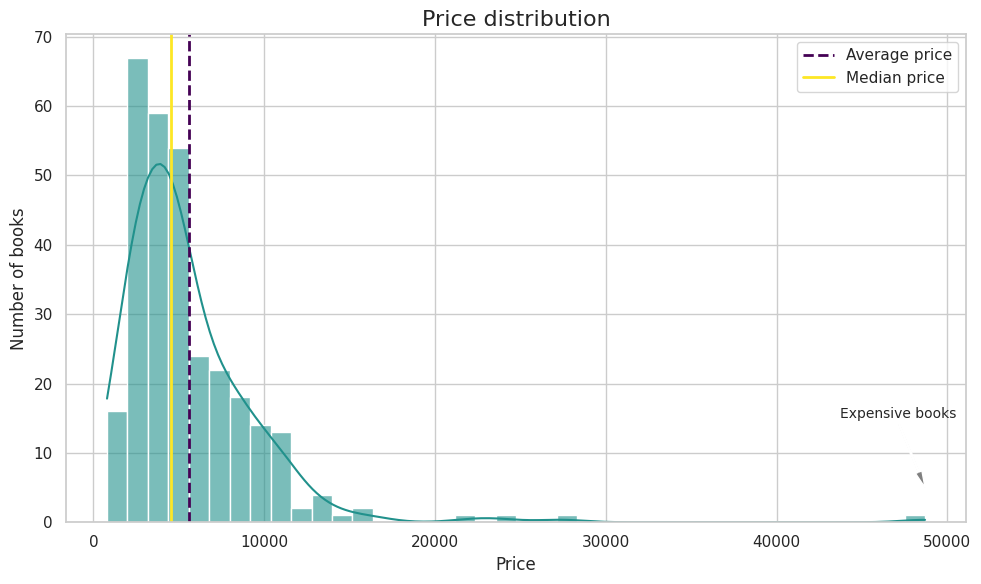

In [629]:
price_data = df_final['price'].dropna()
mean_val = price_data.mean()
median_val = price_data.median()
mode_val = price_data.mode()[0]

plt.figure(figsize=(10, 6))
sns.histplot(price_data, bins=40, kde=True, color=PRIMARY_COLOR, alpha=0.6, edgecolor='white')
plt.axvline(mean_val, color='#440154', linestyle='--', linewidth=2, label='Average price')
plt.axvline(median_val, color='#fde725', linestyle='-', linewidth=2, label='Median price')
plt.annotate('Expensive books', xy=(price_data.max(), 5),xytext=(price_data.max() - 5000, 15),arrowprops=dict(facecolor='gray', width=1, headwidth=5),fontsize=10)

plt.title('Price distribution', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Number of books')
plt.legend()
plt.tight_layout()
plt.show()

The majority of books are affordably priced in the 3,000–5,000 range, but a long right tail of high-priced outliers (reaching up to 50,000) skews the average upward, meaning the median is a better reflection of what a typical buyer would actually pay.

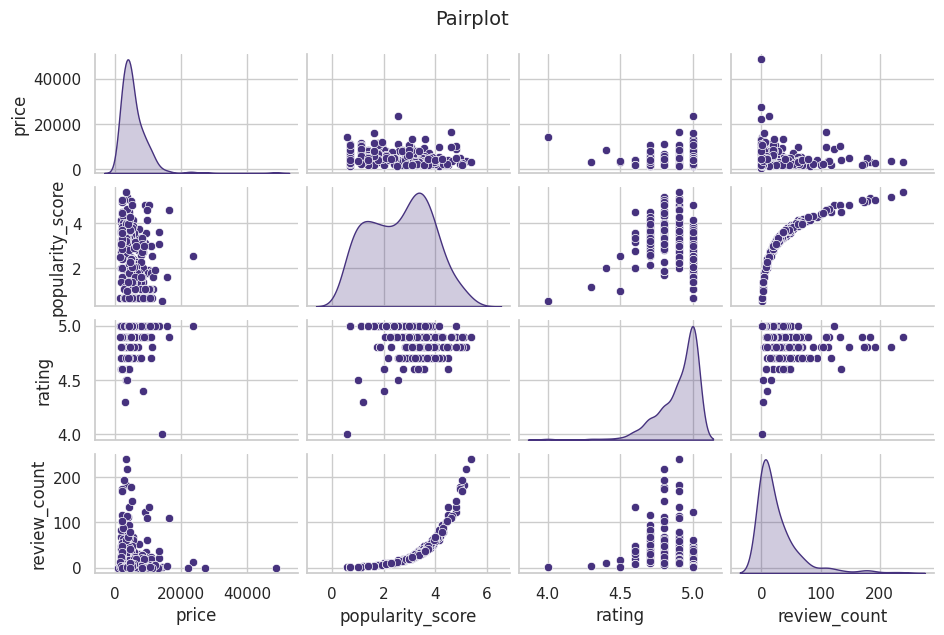

In [630]:
insight_cols = ['price', 'popularity_score', 'rating', 'review_count']
pair_grid = sns.pairplot(df_final[insight_cols], diag_kind='kde',height=1.5,aspect=1.6)
pair_grid.fig.suptitle('Pairplot', y=1.05, fontsize=14)
plt.show()

The pairplot confirms the strong review_count vs popularity_score curve — a clear exponential-like relationship.Distributions for price, popularity, and review_count are heavily right-skewed, meaning a few outliers dominate each.

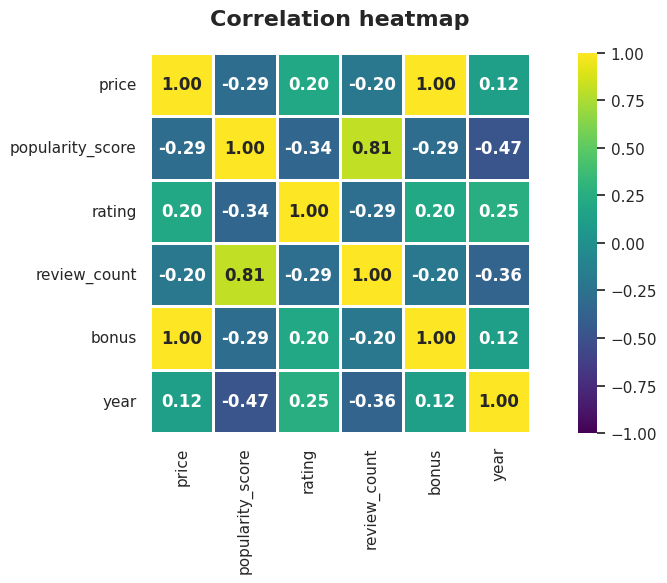

In [631]:
numeric_cols = ['price', 'popularity_score', 'rating', 'review_count', 'bonus', 'year']
corr_matrix = df_final[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='viridis',vmin=-1,vmax=1,square=True,annot_kws={'size': 12, 'weight': 'bold'},linewidths=1,linecolor='white', cbar=True)
plt.title('Correlation heatmap', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The strongest relationship is between popularity_score and review_count (0.73) — more reviews drive higher popularity. All other correlations are near zero, meaning price, rating, bonus, and year are largely independent of each other.

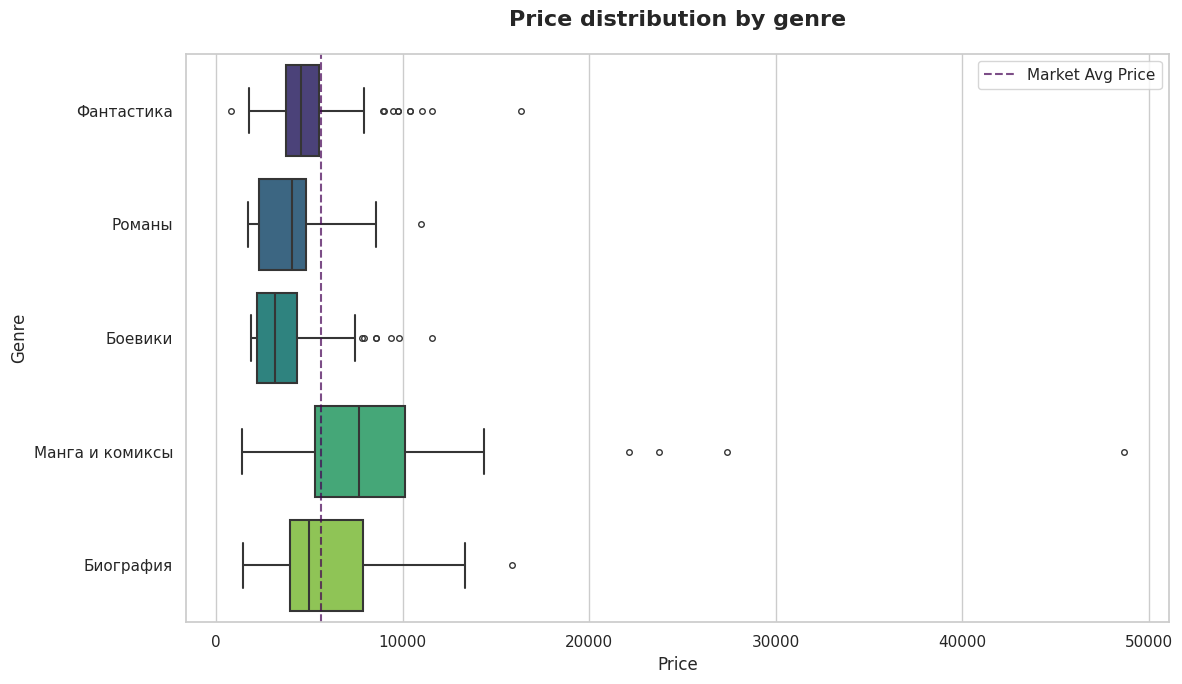

In [632]:
top_genres = df_final['genre'].value_counts().head(5).index
df_subset = df_final[df_final['genre'].isin(top_genres)]

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_subset, x='price', y='genre', palette='viridis',linewidth=1.5,fliersize=4)
plt.axvline(df_final['price'].mean(), color='#440154', linestyle='--', alpha=0.7, label='Market Avg Price')
plt.title('Price distribution by genre', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Most genres cluster well below the market average price (dashed line), but Манга и комиксы (Manga & Comics) stands out with the widest spread and most extreme outliers — suggesting a small number of premium titles significantly inflate its range compared to more consistently priced genres like Боевики (Action) and Романы (Novels).

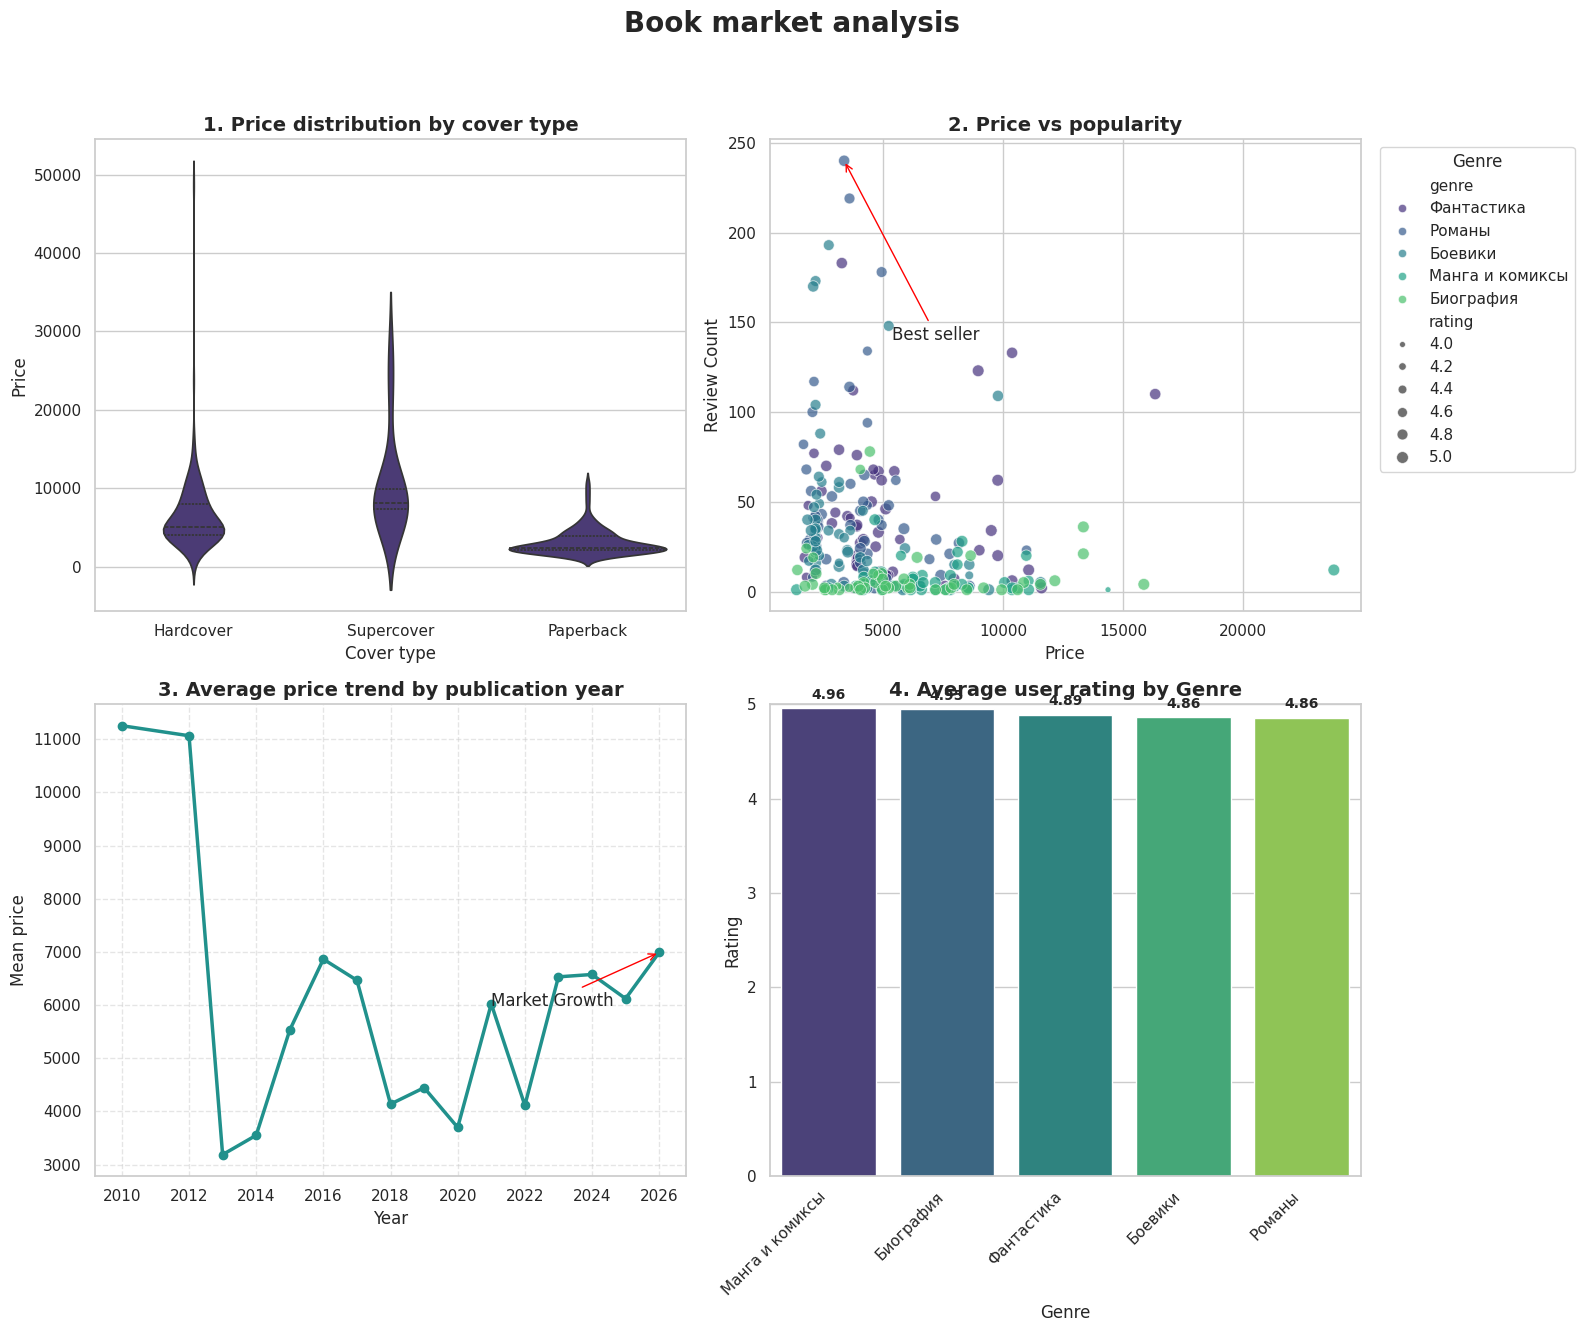

In [633]:
sns.set_theme(style="whitegrid", palette="viridis")
PRIMARY_COLOR = "#21918c"
#1
cover_order = ['Hardcover', 'Supercover', 'Paperback']
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Book market analysis', fontsize=20, fontweight='bold', y=0.98)
sns.violinplot(data=df_final, x='cover_type', y='price', order=cover_order, ax=axes[0, 0], inner="quartile")
axes[0, 0].set_title('1. Price distribution by cover type', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Cover type')
axes[0, 0].set_ylabel('Price')
#2
sns.scatterplot(data=df_final, x='price', y='review_count', hue='genre', size='rating', alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title('2. Price vs popularity', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Price')
axes[0, 1].set_ylabel('Review Count')
axes[0, 1].legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
max_rev = df_final.loc[df_final['review_count'].idxmax()]
axes[0, 1].annotate('Best seller', xy=(max_rev['price'], max_rev['review_count']), xytext=(max_rev['price']+2000, max_rev['review_count']-100),arrowprops=dict(arrowstyle='->', color='red'))
#3
yearly_avg = df_final.groupby('year')['price'].mean()
axes[1, 0].plot(yearly_avg.index, yearly_avg.values, marker='o', color=PRIMARY_COLOR, linewidth=2.5)
axes[1, 0].set_title('3. Average price trend by publication year', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Mean price')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)
axes[1, 0].annotate('Market Growth', xy=(yearly_avg.index[-1], yearly_avg.iloc[-1]), xytext=(yearly_avg.index[-6], yearly_avg.iloc[-1] - 1000), arrowprops=dict(arrowstyle='->', color='red'))
#4
avg_rating = df_final.groupby('genre')['rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating.index, y=avg_rating.values, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('4. Average user rating by Genre', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Genre')
axes[1, 1].set_ylabel('Rating')
axes[1, 1].set_ylim(0, 5)
axes[1, 1].set_xticklabels(avg_rating.index, rotation=45, ha='right')

for i, v in enumerate(avg_rating.values):
    axes[1, 1].text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

1.   Price distribution by cover type - Hardcover and Supercover editions are significantly more expensive than Paperbacks.
2.  Price vs popularity - The most popular books (highest review count) tend to have moderate or low prices.
3. The average price of books has shown consistent growth from around 2005 to 2025, indicating market inflation.
4. Фантастика (Science fiction) leads with the highest ratings, while Биографии (Biographies) and Манга и комиксы (Manga & Comics) have the lowest.

In [634]:
price_counts = df_final['price_bucket'].value_counts().reset_index()
price_counts.columns = ['Price_bucket', 'Count']
price_counts['Price_bucket'] = price_counts['Price_bucket'].astype(str)

fig = px.pie(price_counts, values='Count', names='Price_bucket',title='<b>Segmentation by price bucket</b>',color_discrete_sequence=px.colors.sequential.Viridis,hole=0.4)
fig.update_traces(textinfo='label+percent', textposition='inside',hovertemplate="Count: %{value}<extra></extra>", marker=dict(line=dict(color='#FFFFFF', width=2)))
fig.update_layout(annotations=[dict(text='Price', x=0.5, y=0.5, font_size=20, showarrow=False)],template="plotly_white",width=800,height=600,showlegend=False)
fig.show()


Inventory is heavily concentrated in the mid-to-premium range (5k–8k at 30.6%, 3k–5k at 28.9%), with budget books nearly absent (2.76%), indicating a clear upmarket positioning strategy.

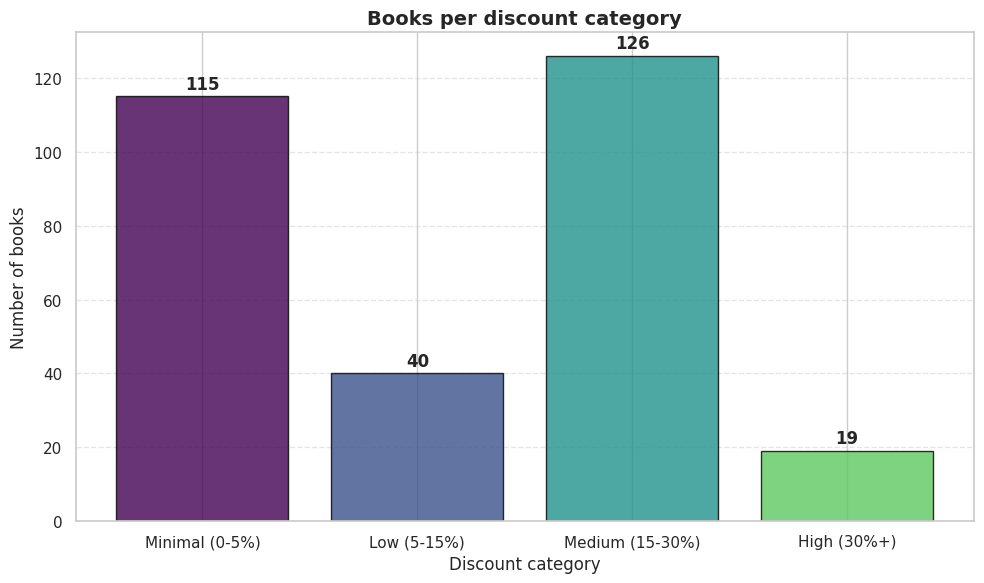

In [635]:
counts = df_final['discount_bin'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
colors = ['#440154', '#3b528b', '#21918c', '#5ec962']
bars = plt.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='black', alpha=0.8)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval),
             ha='center', va='bottom', fontweight='bold')

plt.title('Books per discount category', fontsize=14, fontweight='bold')
plt.xlabel('Discount category', fontsize=12)
plt.ylabel('Number of books', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('discount_distribution.png')
plt.show()

Most books are minimally discounted (0-5%), while deep or moderate discounts are rare — suggesting a full-price-first pricing strategy with selective heavy markdowns.

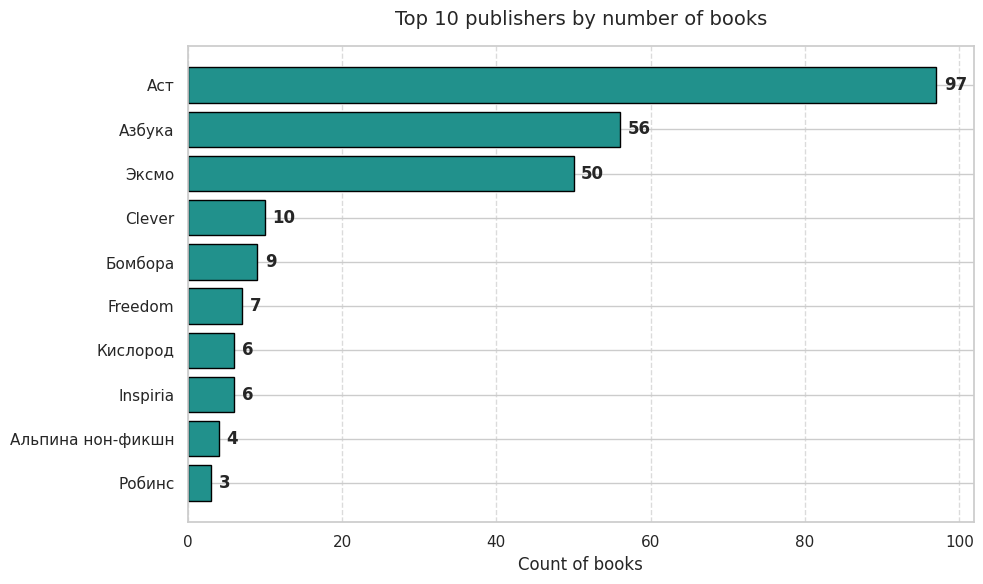

In [636]:
top_10 = df_final['publisher'].value_counts().head(10).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
bars = plt.barh(top_10.index, top_10.values, color=PRIMARY_COLOR, edgecolor='black')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center', fontweight='bold')
plt.title('Top 10 publishers by number of books', fontsize=14, pad=15)
plt.xlabel('Count of books')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 10 publishers by number of books  Аст and Эксмо lead the market, publishing far more books than competitors, signifying strong dominance and wide catalogues.

In [637]:
df_grouped = df_final.groupby(['genre', 'price_bucket'])['review_count'].sum().reset_index()

fig3 = px.bar(df_grouped,x='genre',y='review_count',color='price_bucket',color_discrete_sequence=['#440154','#31688e','#35b779','#fde725','#21918c','#90d743'],title='Review count by cenre and price bucket',barmode='group')
fig3.update_layout(template='plotly_white', xaxis_tickangle=-45)
fig3.show()

Фантастика and Романы lead in reviews across all price ranges, while Биография and Манга remain niche. Mid-tier pricing (3-5k) consistently drives the most engagement.

In [638]:
top_publishers = df_final.groupby('publisher')['review_count'].sum().nlargest(8).index
df_pub = df_final[df_final['publisher'].isin(top_publishers)]

fig5 = px.violin(df_pub,x='publisher',y='rating',color='publisher',color_discrete_sequence=['#440154','#31688e','#35b779','#fde725','#21918c','#90d743','#482878','#26828e'],box=True,points='outliers',title='Rating distribution by top 8 publishers')
fig5.update_layout(template='plotly_white', xaxis_tickangle=-45, showlegend=False)
fig5.show()

Most publishers cluster heavily around rating 5, but Эксмо and Аст show the widest spread — reaching as low as 1-2, suggesting larger and more diverse catalogs with inconsistent quality compared to smaller publishers.

# Cross comparison

In [639]:
df_loveread=pd.read_csv('loveread.csv')
df_flip=df_final.copy()

In [640]:
df_merged = pd.merge(
    df_loveread,
    df_flip,
    on='title',
    how='inner',
    suffixes=('', '_drop')
)
cols_to_drop = [c for c in df_merged.columns if '_drop' in c]
df_merged = df_merged.drop(columns=cols_to_drop)

print(f"Final Merged Dataset:{df_merged.shape[0]} books and {df_merged.shape[1]} features.")

Final Merged Dataset:53 books and 47 features.


In [641]:
df_merged['stock'] = pd.to_numeric(df_merged['stock'], errors='coerce').fillna(0).astype(int)

In [642]:
market_gap = df_merged.groupby('genre_simple')[['review_count', 'stock']].sum()
market_gap['gap_score'] = (market_gap['review_count'] + 1) / (market_gap['stock'] + 1)
market_gap.sort_values(by='gap_score', ascending=False).head(5)

,review_count,stock,gap_score
genre_simple,,,
Классический детектив,682,8211975926290448384,8.317121e-17
Научная фантастика,395,7108992000000000000,5.570410e-17
Современные любовные романы,165,3554496000000000000,4.670142e-17
Триллер,99,3554496000000000000,2.813338e-17
Современная русская и зарубежная проза,223,8886240000000000000,2.520751e-17


In [643]:
df_merged.columns

Index(['title', 'genre', 'description', 'author', 'publisher', 'year', 'isbn',
       'pages', 'language', 'pages_mov', 'book_age', 'desc_word_count',
       'crime_book', 'authors_max_page', 'min_year_by_genre',
       'author_book_count', 'genre_avg_pages', 'page_deviation',
       'relative_page_length', 'book_size', 'year_era', 'genre_encoded',
       'book_size_label', 'year_era_label', 'pages_scaled', 'age_normalized',
       'genre_simple', 'book_size_encoded', 'year_dt', 'year_missing', 'cover',
       'cover_type', 'price', 'discount', 'original_price', 'savings_tenge',
       'price_bucket', 'bonus', 'price_per_bonus', 'rating', 'review_count',
       'popularity_score', 'stock', 'stock_status', 'discount_bin', 'is_old',
       'age_category'],
      dtype='object')

In [644]:
price_opt = df_merged.groupby(['book_size_label', 'genre_simple'])[['price', 'popularity_score']].mean()
price_opt.sort_values(by='price', ascending=False).head(5)

,,price,popularity_score
book_size_label,genre_simple,,
1,Боевая фантастика и фэнтези,9781.0,3.044522
0,Фэнтези,7741.0,2.282174
1,Фэнтези,7492.5,2.698757
0,Научная фантастика,6478.0,4.218760
2,Современная русская и зарубежная проза,4948.0,3.492083


In [645]:
age_q = df_merged['book_age'].quantile(0.75)
pop_q = df_merged['popularity_score'].quantile(0.25)

dead_stock = df_merged[(df_merged['book_age'] >= age_q) &
                       (df_merged['popularity_score'] <= pop_q) &
                       (df_merged['stock'] > 0)]

print(f"Found {len(dead_stock)} high-risk items")
dead_stock[['title', 'stock', 'price']].sort_values(by='stock', ascending=False).head()

Found 5 high-risk items


,title,stock,price
8,Мобильник,1777248000000000000,4356
9,Куджо,1777248000000000000,3933
12,Темная Башня,1777248000000000000,11563
46,Vita Nostra,1777248000000000000,3919
52,Происхождение,1777248000000000000,3175


In [646]:
discount_active = df_merged[df_merged['discount'] > 0].copy()
discount_active['discount_efficiency'] = discount_active['popularity_score'] / discount_active['discount']

discount_perf = discount_active.groupby('genre_simple').agg({
    'discount_efficiency': 'mean',
    'popularity_score': 'mean',
    'discount': 'mean'})
discount_perf.sort_values(by='discount_efficiency', ascending=False).head(10)

,discount_efficiency,popularity_score,discount
genre_simple,,,
Ужасы,0.263356,3.950341,15.000000
Современная русская и зарубежная проза,0.248786,3.731795,15.000000
Историческая проза,0.234227,3.513409,15.000000
Научная фантастика,0.198017,3.960334,20.000000
Классический детектив,0.171431,3.334374,19.615385
Фэнтези,0.140129,2.802577,20.000000


In [647]:
publisher_power = df_merged.groupby('publisher').agg({'price': 'mean','rating': 'mean','title': 'count'}).query('title > 5')
publisher_power.sort_values(by=['rating', 'price'], ascending=False).head(10)

,price,rating,title
publisher,,,
"АСТ, АСТ Москва",5476.444444,4.933333,9
Эксмо,2652.235294,4.852941,17


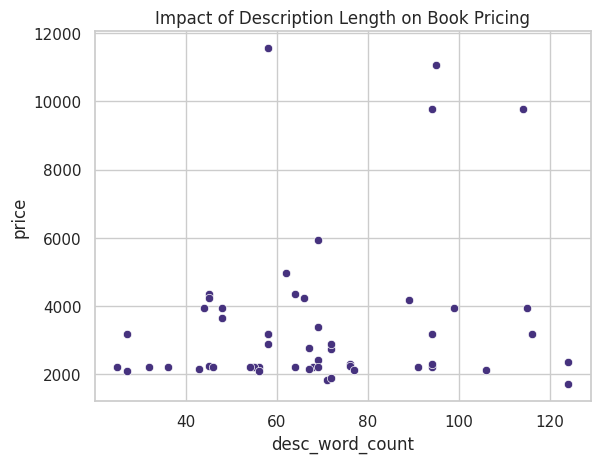

In [648]:
import seaborn as sns
sns.scatterplot(data=df_merged, x='desc_word_count', y='price')
plt.title('Impact of Description Length on Book Pricing')
plt.show()

In [649]:
author_impact = df_merged.groupby('author').agg({'author_book_count': 'first','popularity_score': 'mean','rating': 'mean'}).query('author_book_count > 1')

correlation = author_impact['author_book_count'].corr(author_impact['popularity_score'])
print(f"Correlation between Prolificness and Popularity: {correlation:.2f}")

Correlation between Prolificness and Popularity: -0.28


In [650]:
cover_analysis = df_merged.groupby('cover_type').agg({'price': 'mean','rating': 'mean','popularity_score': 'mean'})
cover_analysis

,price,rating,popularity_score
cover_type,,,
Hardcover,5409.444444,4.877778,3.329847
Paperback,2429.6,4.828571,3.490340


# Machine Learning

One-Hot Encoding for Categorical Features

In [651]:
categorical_cols = ['genre', 'publisher', 'cover_type', 'discount_bin', 'price_bucket', 'stock_status', 'age_category']

df_encoded = pd.get_dummies(df_final, columns=categorical_cols, drop_first=True)
print(f"Original DataFrame shape: {df_final.shape}")
print(f"Encoded DataFrame shape: {df_encoded.shape}")
display(df_encoded.head())

Original DataFrame shape: (300, 22)
Encoded DataFrame shape: (300, 79)


,title,year,year_missing,cover,price,discount,original_price,savings_tenge,bonus,price_per_bonus,...,cover_type_Supercover,discount_bin_Low (5-15%),discount_bin_Medium (15-30%),discount_bin_High (30%+),price_bucket_Economy (1.5-3k),price_bucket_Mid (3-5k),price_bucket_Premium (5-8k),price_bucket_Luxury (8k+),stock_status_Preorder,age_category_New
0,Кэрри,2013,False,твердый переплет,3765,0.0,3765.0,0.0,38,99.08,...,False,False,False,False,False,True,False,False,False,False
1,Система «Спаси-Себя-Сам» для Главного Злодея. ...,2024,False,твердый переплет,9509,20.0,11886.0,2377.0,95,100.09,...,False,False,True,False,False,False,False,True,False,True
2,Точка зрения Всеведущего читателя. Том 2,2026,False,твердый переплет,4551,30.0,6501.0,1950.0,46,98.93,...,False,False,True,False,False,True,False,False,False,True
3,Перси Джексон и море Чудовищ,2022,False,твердый переплет,3919,20.0,4899.0,980.0,39,100.49,...,False,False,True,False,False,True,False,False,False,False
4,Кэрри,2020,False,мягкая обложка,2133,0.0,2133.0,0.0,21,101.57,...,False,False,False,False,True,False,False,False,False,False


In [652]:
df_encoded.isna().sum()

,0
title,0
year,2
year_missing,0
cover,0
price,0
...,...
price_bucket_Mid (3-5k),0
price_bucket_Premium (5-8k),0
price_bucket_Luxury (8k+),0
stock_status_Preorder,0


In [653]:
from sklearn.model_selection import train_test_split
y = df_encoded['price']
X = df_encoded.drop(columns=['price', 'title', 'cover', 'review_count', 'stock', 'original_price', 'savings_tenge'])
X = X.dropna(axis=1)
X = X.fillna(X.mean(numeric_only=True))
y = y.fillna(y.mean())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (240, 68)
Shape of X_test: (60, 68)
Shape of y_train: (240,)
Shape of y_test: (60,)


### Train a Linear Regression Model

In [654]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae:.2f}")
print(f"  Mean Squared Error (MSE): {mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"  R-squared (R2): {r2:.2f}")

Linear Regression Model Performance:
  Mean Absolute Error (MAE): 11.89
  Mean Squared Error (MSE): 219.02
  Root Mean Squared Error (RMSE): 14.80
  R-squared (R2): 1.00


In [655]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linear_model.coef_
})

coefficients['Absolute_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

display(coefficients.head(10))

,Feature,Coefficient,Absolute_Coefficient
2,bonus,99.955516,99.955516
64,price_bucket_Premium (5-8k),53.539999,53.539999
62,price_bucket_Economy (1.5-3k),48.380745,48.380745
63,price_bucket_Mid (3-5k),46.711902,46.711902
65,price_bucket_Luxury (8k+),43.664299,43.664299
38,publisher_Комильфо. комфедерация. зарубежные к...,42.978660,42.978660
32,publisher_Иностранка / колибри,-38.203405,38.203405
18,publisher_Азбука - классика,-33.864093,33.864093
16,publisher_Unknown,33.707916,33.707916
3,price_per_bonus,30.841867,30.841867


### Train a Random Forest Regressor Model

In [656]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Model Performance:
  Mean Absolute Error (MAE): 78.02
  Mean Squared Error (MSE): 49472.69
  Root Mean Squared Error (RMSE): 222.42
  R-squared (R2): 1.00


### Random Forest Feature Importance

In [657]:
feature_importances_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importances_rf = feature_importances_rf.sort_values(by='Importance', ascending=False)

display(feature_importances_rf.head(15))

,Feature,Importance
2,bonus,0.974509
3,price_per_bonus,0.010662
66,stock_status_Preorder,0.004226
58,cover_type_Supercover,0.003897
67,age_category_New,0.003508
64,price_bucket_Premium (5-8k),0.000474
45,publisher_Рипол классик,0.000456
17,publisher_Азбука,0.000378
63,price_bucket_Mid (3-5k),0.000302
59,discount_bin_Low (5-15%),0.000268


## Text Analysis (NLP)

In [658]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from textblob import TextBlob
import matplotlib.pyplot as plt
import re

try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')
try:
    nltk.data.find('taggers/averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger')

russian_stopwords = stopwords.words('russian')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### Preprocessing Text Data

In [659]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^а-яa-z\s]', '', text)
        tokens = text.split()
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in russian_stopwords and word not in stopwords.words('english')]
        return ' '.join(tokens)
    return ''

df_merged['cleaned_description'] = df_merged['description'].apply(clean_text)

print(df_merged[['description', 'cleaned_description']].head())

                                         description  \
0  В романе "Зло под солнцем" Эркюлю Пуаро предст...   
1  Сыщик Эркюль Пуаро хоть и невелик ростом, одна...   
2  Пятеро джентльменов решили организовать клуб «...   
3  Мисс Марпл - кто она? Тихая старушка - "божий ...   
4  Мисс Джейн Марпл, дотошная и обаятельная пожил...   

                                 cleaned_description  
0  романе зло солнцем эркюлю пуаро предстоит побы...  
1  сыщик эркюль пуаро невелик ростом однако силам...  
2  пятеро джентльменов решили организовать клуб в...  
3  мисс марпл тихая старушка божий одуванчик гени...  
4  мисс джейн марпл дотошная обаятельная пожилая ...  


### Word Cloud of Book Descriptions

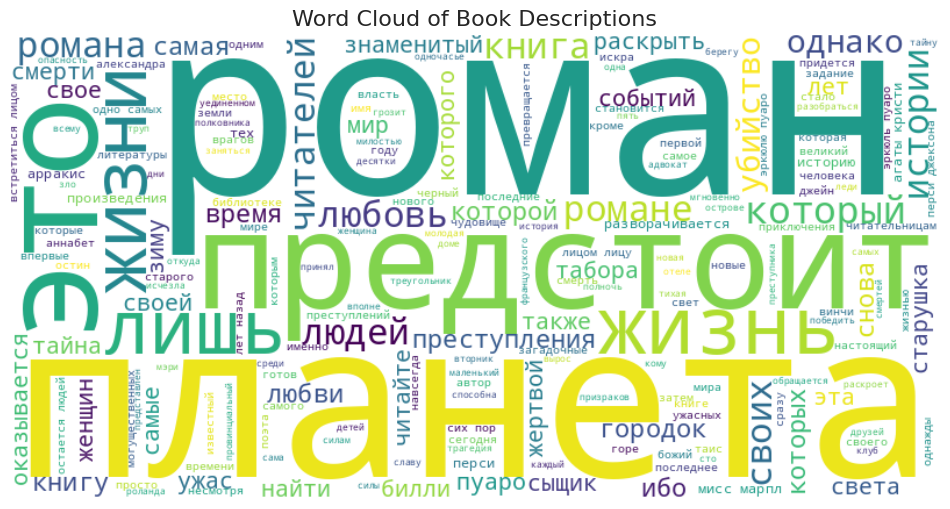

In [660]:
all_descriptions = ' '.join(df_merged['cleaned_description'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_descriptions)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Book Descriptions', fontsize=16)
plt.show()

### Sentiment Analysis of Book Descriptions

Sentiment Distribution:
description_sentiment
Neutral    53
Name: count, dtype: int64


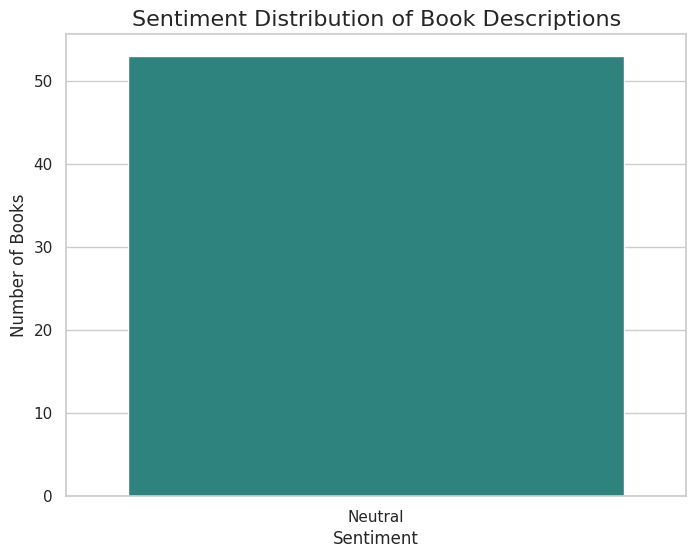

In [661]:
from textblob import TextBlob

def get_sentiment(text):
    if isinstance(text, str):
        analysis = TextBlob(text)
        if analysis.sentiment.polarity > 0:
            return 'Positive'
        elif analysis.sentiment.polarity < 0:
            return 'Negative'
        else:
            return 'Neutral'
    return 'Neutral'

df_merged['description_sentiment'] = df_merged['cleaned_description'].apply(get_sentiment)

print("Sentiment Distribution:")
print(df_merged['description_sentiment'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='description_sentiment', data=df_merged, palette='viridis')
plt.title('Sentiment Distribution of Book Descriptions', fontsize=16)
plt.xlabel('Sentiment')
plt.ylabel('Number of Books')
plt.show()